Kept 74 cuisines, 398244 rows
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     93.24
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:09:52   Log-Likelihood:            -1.4939e+06
No. Observations:              376209   AIC:                         2.988e+06
Df Residuals:                  376130   BIC:                         2.989e+06
Df Model:                          78                                         
Covariance Type:            nonrobust                                         
                                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

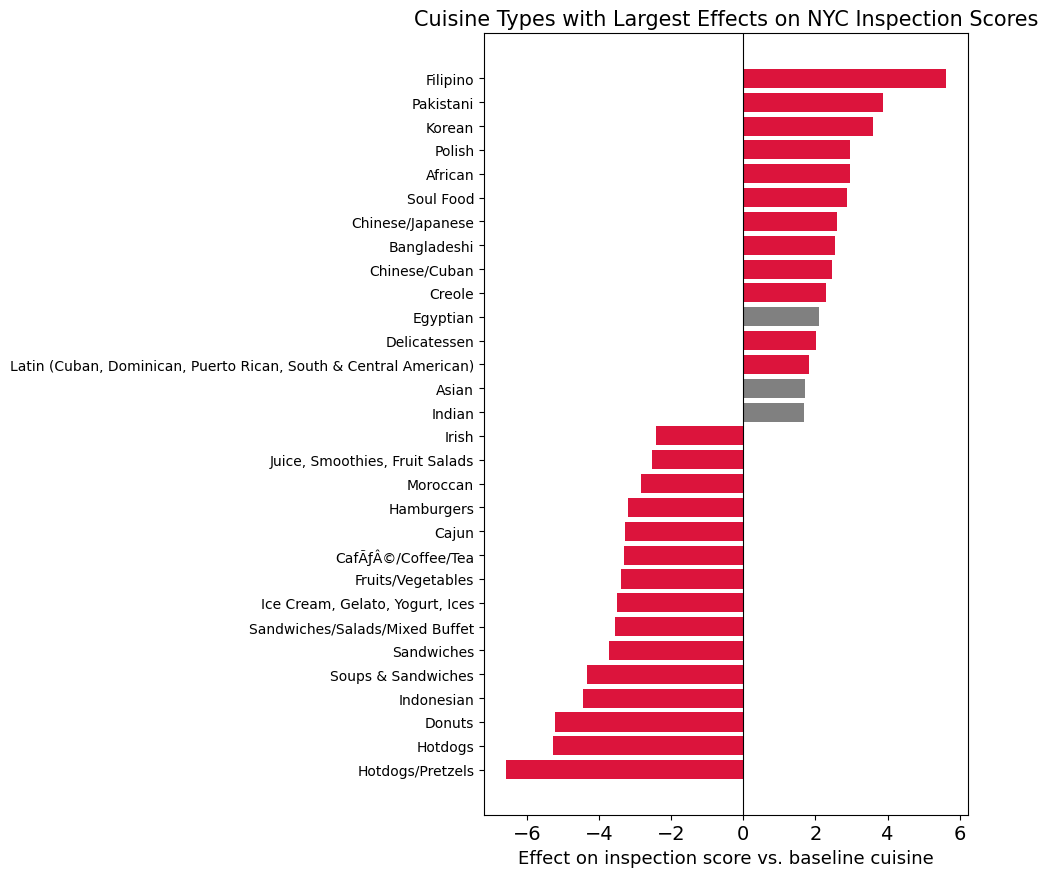

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Load cleaned data ---
df = pd.read_csv("../data/cleaned_inspections.csv")

# --- Extract year from inspection date ---
df["inspection_date"] = pd.to_datetime(df["inspection_date"], errors="coerce")
df["year"] = df["inspection_date"].dt.year

# --- Filter to cuisines with enough observations ---
cuisine_counts = df["cuisine_description"].value_counts()
common_cuisines = cuisine_counts[cuisine_counts >= 100].index
df_filtered = df[df["cuisine_description"].isin(common_cuisines)].copy()

print(f"Kept {df_filtered['cuisine_description'].nunique()} cuisines, {len(df_filtered)} rows")

# --- Multi-variable OLS ---
model = smf.ols("score ~ C(cuisine_description) + C(boro) + year", data=df_filtered).fit()
print(model.summary())

# --- Save full results table ---
results_table = pd.DataFrame({
    "coef": model.params,
    "p_value": model.pvalues,
    "conf_low": model.conf_int()[0],
    "conf_high": model.conf_int()[1]
})
results_table.to_csv("../output/cuisine_score_ols_results.csv")

# --- Extract cuisine coefficients only, sorted ---
coefs = model.params.filter(like="cuisine_description").sort_values()
pvals = model.pvalues.filter(like="cuisine_description")

# --- Keep only top 15 and bottom 15 cuisines by effect size ---
coefs_top_bottom = pd.concat([coefs.head(15), coefs.tail(15)])
pvals_top_bottom = pvals[coefs_top_bottom.index]
labels_top_bottom = [c.split("[T.")[1].rstrip("]") for c in coefs_top_bottom.index]

# --- Visualization ---
plt.rcParams.update({'font.size': 14})
n_bars = len(labels_top_bottom)
fig, ax = plt.subplots(figsize=(10, n_bars * 0.3))

colors = ["crimson" if p < 0.05 else "gray" for p in pvals_top_bottom]
ax.barh(labels_top_bottom, coefs_top_bottom.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Effect on inspection score vs. baseline cuisine", fontsize=13)
ax.set_title("Cuisine Types with Largest Effects on NYC Inspection Scores", fontsize=15)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.savefig("../output/cuisine_score_coefficients.png", dpi=200)
plt.show()

**Figure 1.** Estimated effect on DOHMH inspection score for the 15 cuisine types with the largest positive and negative deviations from the baseline cuisine, controlling for borough and inspection year. Higher (more positive) values indicate worse average inspection scores. Red bars denote statistically significant differences (p < 0.05).